In [ ]:
import numpy as np

def load_data():
    try:
        vectors = np.load("./hafez_embeddings.npy", allow_pickle=False)
        print("Embeddings loaded successfully.")
        return vectors
    except FileNotFoundError:
        print("Error: Could not find 'hafez_embeddings.npy'.")
        exit()

vectors = load_data()

Embeddings loaded successfully.


In [ ]:
import json

with open("./hafez_poems.json",'r',encoding='utf-8') as data:
  poems = json.load(data)
  data.close()


In [ ]:
len(vectors[0])
poems[0]

'دی پیر می فروش که ذکرش به خیر باد گفتا شراب نوش و غم دل ببر ز یاد'

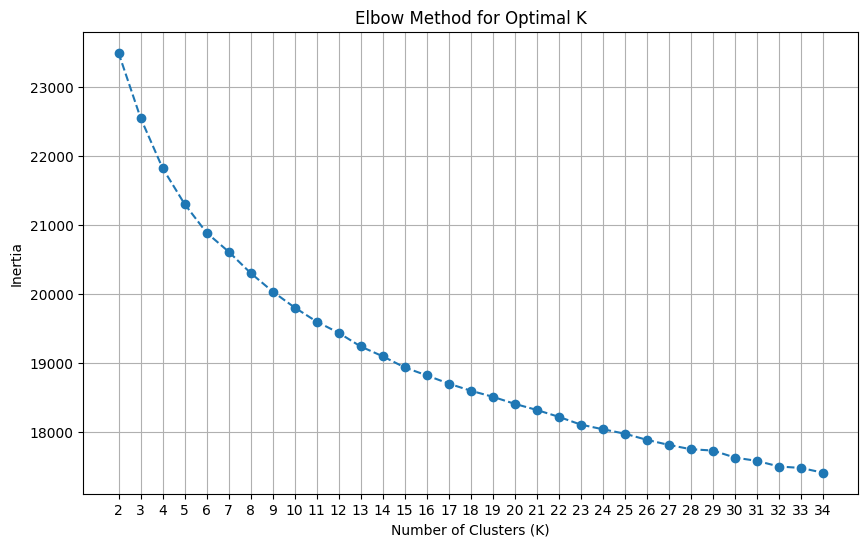

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


inertia_values = []
k_range = range(2, 35)

for k in k_range:
  #define the model
  Kmeanss = KMeans(init="k-means++", n_clusters=k, n_init=10, random_state=0)
  #fixing model
  Kmeanss.fit(vectors)

  inertia_values.append(Kmeanss.inertia_)


plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#n_clusters=34,10 cheked , starting the process with 15 clusters
Kmeanss = KMeans(init="k-means++", n_clusters=15, n_init=10, random_state=0)
#fixing model
Kmeanss.fit(vectors)

labels = Kmeanss.labels_


clusters = {}

for idx, vec in enumerate(vectors):

    cluster_label = labels[idx]
    if cluster_label not in clusters:

        clusters[int(cluster_label)] = []
    clusters[cluster_label].append(vec.)


try:
    for beyt in clusters[5][:5]:
        print(f"- {beyt}")
except KeyError:
    print("error")


TypeError: only length-1 arrays can be converted to Python scalars

In [ ]:
import  json
with open('clusters.json', 'w',encoding='utf-8') as fp:
    json.dump(clusters, fp)
    fp.close()


TypeError: Object of type ndarray is not JSON serializable

In [ ]:
from sentence_transformers import util


representative_verses = {}

for cluster_id in range(0,15):

  indices_in_cluster = [idx for idx, label in enumerate(Kmeanss.labels_) if label == cluster_id]
  vectors_in_cluster = vectors[indices_in_cluster]
  center_vector = Kmeanss.cluster_centers_[cluster_id]
  similarities = util.cos_sim(center_vector, vectors_in_cluster)
  local_best_index = np.argmax(similarities)
  global_best_index = indices_in_cluster[local_best_index]
  representative_poem = poems[global_best_index]
  representative_verses[cluster_id] = representative_poem
  print(f"  > {representative_verses[cluster_id]}")

  > ذکرش به خیر ساقی فرخنده فال من کز در مدام با قدح و ساغر آمدی
  > آتش مهر تو را حافظ عجب در سر گرفت آتش دل کی به آب دیده بنشانم چو شمع
  > نام حافظ گر برآید بر زبان کلک دوست از جناب حضرت شاهم بس است این ملتمس
  > دارای جهان نصرت دین خسرو کامل یحیی بن مظفر ملک عالم عادل
  > طرف چمن و طواف بستان بی لاله عذار خوش نباشد
  > نه هر که طرف کله کج نهاد و تند نشست کلاه داری و آیین سروری داند
  > ای نسیم سحری خاک در یار بیار که کند حافظ از او دیده دل نورانی
  > رتبت دانش حافظ به فلک برشده بود کرد غمخواری شمشاد بلندت پستم
  > خود را بکش ای بلبل از این رشک که گل را با باد صبا وقت سحر جلوه گری بود
  > مزاج دهر تبه شد در این بلا حافظ کجاست فکر حکیمی و رای برهمنی
  > بتا چون غمزه‌ات ناوک فشاند دل مجروح من پیشش سپر باد
  > عاشقی را که چنین باده شبگیر دهند کافر عشق بود گر نشود باده پرست
  > گفتمش سلسله زلف بتان از پی چیست گفت حافظ گله‌ای از دل شیدا می‌کرد
  > نوش کن جام شراب یک منی تا بدان بیخ غم از دل برکنی
  > تویی آن گوهر پاکیزه که در عالم قدس ذکر خیر تو بود حاصل تسبیح ملک
